<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/tau_kde_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# ============================================================
# 1. Setup
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import t, gaussian_kde
import matplotlib.pyplot as plt
import io

plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

# ============================================================
# 2. Sample race data
# ============================================================

# You can now paste your data directly here inside the triple quotes.
# Ensure the columns are separated by tabs or spaces.
raw_data = """Tab	Horse	DOD	EM	PP
1	ON JUST TERMS	-5.5	19.5	34
2	BLOWIN' SMOKE	-2	3	9.5
4	YES I BELIEVE	3.5	0	4.5
5	ALMA MATER	-1.5	7	8
6	FORBIDDEN APPLE	4.5	7	8.5
7	TANGO RHYTHM	7	2.5	5.5
8	KUNAPIPI	1.5	6	5
9	DASHING DIVA	9.5	8	34
10	HOT NOVA	13	13.5	21
11	LINE OF THOUGHT	2.5	8	17
12	RIVER BEAUTY	14	15.5	41
13	RUN TEDDY RUN	4	9	34
14	WAR TACTICS	5	5.5	26
"""

df = pd.read_csv(io.StringIO(raw_data), sep="\\s+" if "\t" not in raw_data else "\t")
df

,Tab,Horse,DOD,EM,PP
0,1,ON JUST TERMS,-5.500,19.500,34.000
1,2,BLOWIN' SMOKE,-2.000,3.000,9.500
2,4,YES I BELIEVE,3.500,0.000,4.500
3,5,ALMA MATER,-1.500,7.000,8.000
4,6,FORBIDDEN APPLE,4.500,7.000,8.500
5,7,TANGO RHYTHM,7.000,2.500,5.500
6,8,KUNAPIPI,1.500,6.000,5.000
7,9,DASHING DIVA,9.500,8.000,34.000
8,10,HOT NOVA,13.000,13.500,21.000
9,11,LINE OF THOUGHT,2.500,8.000,17.000


In [17]:
# ============================================================
# 3. Thompson Tau helper functions
# ============================================================

def thompson_tau_threshold(n, alpha=0.05):
    """
    Compute Thompson Tau threshold (in SD units) for sample size n.
    Uses two-tailed t-distribution with df = n - 2.
    """
    df = n - 2
    t_crit = t.ppf(1 - alpha / 2, df)  # two-tailed
    denom = np.sqrt(n) * np.sqrt(df + t_crit**2)
    tau = t_crit * (n - 1) / denom
    return tau

def tau_distance(series, alpha=0.05):
    """
    Compute TauDistance for each value in a metric series.
    Returns:
        mean, sd, tau, max_dev, tau_distance_array
    """
    x = np.asarray(series, dtype=float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    tau = thompson_tau_threshold(n, alpha=alpha)
    max_dev = tau * sd
    dev = np.abs(x - mean)
    tau_dist = dev - max_dev
    return mean, sd, tau, max_dev, tau_dist


In [18]:
# ============================================================
# 4. Apply Tau to DOD, EM, PP
# ============================================================

metrics = ["DOD", "EM", "PP"]
tau_results = {}

for m in metrics:
    mean, sd, tau, max_dev, tau_dist = tau_distance(df[m], alpha=0.05)
    df[f"{m}_TauDist"] = tau_dist
    df[f"{m}_OutlierFlag"] = np.where(tau_dist > 0, "OUTLIER", "NORMAL")
    tau_results[m] = {
        "mean": mean,
        "sd": sd,
        "tau": tau,
        "max_dev": max_dev,
    }

df[["Horse", "DOD", "DOD_TauDist", "DOD_OutlierFlag",
    "EM", "EM_TauDist", "EM_OutlierFlag",
    "PP", "PP_TauDist", "PP_OutlierFlag"]]


,Horse,DOD,DOD_TauDist,DOD_OutlierFlag,EM,EM_TauDist,EM_OutlierFlag,PP,PP_TauDist,PP_OutlierFlag
0,ON JUST TERMS,-5.500,-0.666,NORMAL,19.500,1.505,OUTLIER,34.000,-9.572,NORMAL
1,BLOWIN' SMOKE,-2.000,-4.166,NORMAL,3.000,-4.918,NORMAL,9.500,-14.918,NORMAL
2,YES I BELIEVE,3.500,-9.666,NORMAL,0.000,-1.918,NORMAL,4.500,-9.918,NORMAL
3,ALMA MATER,-1.500,-4.666,NORMAL,7.000,-8.918,NORMAL,8.000,-13.418,NORMAL
4,FORBIDDEN APPLE,4.500,-10.204,NORMAL,7.000,-8.918,NORMAL,8.500,-13.918,NORMAL
5,TANGO RHYTHM,7.000,-7.704,NORMAL,2.500,-4.418,NORMAL,5.500,-10.918,NORMAL
6,KUNAPIPI,1.500,-7.666,NORMAL,6.000,-7.918,NORMAL,5.000,-10.418,NORMAL
7,DASHING DIVA,9.500,-5.204,NORMAL,8.000,-9.918,NORMAL,34.000,-9.572,NORMAL
8,HOT NOVA,13.000,-1.704,NORMAL,13.500,-4.495,NORMAL,21.000,-22.572,NORMAL
9,LINE OF THOUGHT,2.500,-8.666,NORMAL,8.000,-9.918,NORMAL,17.000,-22.418,NORMAL


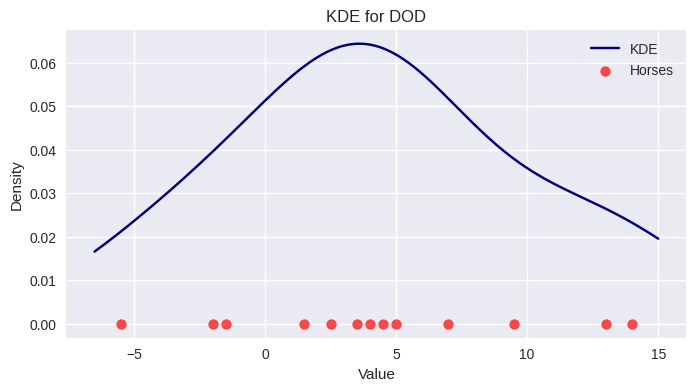

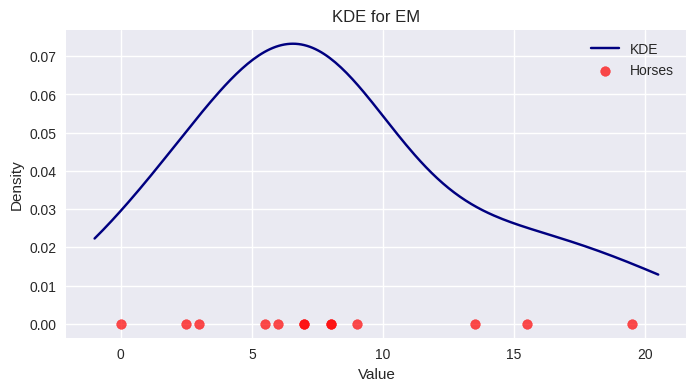

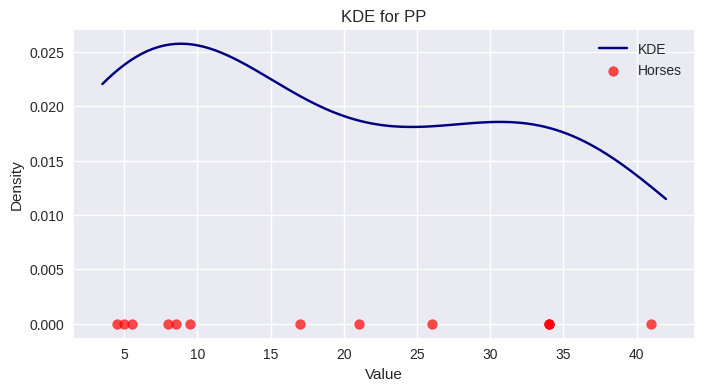

In [19]:
# ============================================================
# 5. KDE for each metric (for visual context)
# ============================================================

def plot_kde_with_points(series, title):
    x = np.asarray(series, dtype=float)
    kde = gaussian_kde(x)
    xs = np.linspace(x.min() - 1, x.max() + 1, 200)
    ys = kde(xs)

    plt.figure(figsize=(8, 4))
    plt.plot(xs, ys, label="KDE", color="navy")
    plt.scatter(x, np.zeros_like(x), color="red", alpha=0.7, label="Horses")
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

for m in metrics:
    plot_kde_with_points(df[m], f"KDE for {m}")


In [20]:
# ============================================================
# 6. Tau-based outlier filter as main logic
# ============================================================

# Example: build a composite outlier score
# Positive TauDist = bad outlier (we want to penalise)
# You can also separate good vs bad if you use signed deviations.

def composite_outlier_score(row):
    """
    Simple example:
    - Penalise horses that are outliers on EM or PP or DOD.
    - You can weight metrics differently.
    """
    score = 0.0

    # weights (tune these)
    w_dod = 0.5
    w_em = 1.0
    w_pp = 1.0

    # add only positive TauDist (true outliers)
    score += w_dod * max(0, row["DOD_TauDist"])
    score += w_em * max(0, row["EM_TauDist"])
    score += w_pp * max(0, row["PP_TauDist"])

    return score

df["OutlierScore"] = df.apply(composite_outlier_score, axis=1)

df[["Horse", "DOD_OutlierFlag", "EM_OutlierFlag", "PP_OutlierFlag", "OutlierScore"]]


,Horse,DOD_OutlierFlag,EM_OutlierFlag,PP_OutlierFlag,OutlierScore
0,ON JUST TERMS,NORMAL,OUTLIER,NORMAL,1.505
1,BLOWIN' SMOKE,NORMAL,NORMAL,NORMAL,0.000
2,YES I BELIEVE,NORMAL,NORMAL,NORMAL,0.000
3,ALMA MATER,NORMAL,NORMAL,NORMAL,0.000
4,FORBIDDEN APPLE,NORMAL,NORMAL,NORMAL,0.000
5,TANGO RHYTHM,NORMAL,NORMAL,NORMAL,0.000
6,KUNAPIPI,NORMAL,NORMAL,NORMAL,0.000
7,DASHING DIVA,NORMAL,NORMAL,NORMAL,0.000
8,HOT NOVA,NORMAL,NORMAL,NORMAL,0.000
9,LINE OF THOUGHT,NORMAL,NORMAL,NORMAL,0.000


In [21]:
# ============================================================
# 7. Integrate with probabilities (toy example)
# ============================================================

# Suppose you have a base rating (e.g., EM) and you want to
# down-weight bad outliers before converting to probabilities.

# Step 1: invert EM (lower is better) into a positive strength
df["EM_Strength"] = df["EM"].max() - df["EM"] + 1  # simple transform

# Step 2: apply outlier penalty
penalty_scale = 0.2  # tune this
df["EM_Adjusted"] = df["EM_Strength"] * np.exp(-penalty_scale * df["OutlierScore"])

# Step 3: softmax to probabilities
def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - x.max()
    ex = np.exp(x)
    return ex / ex.sum()

df["Prob"] = softmax(df["EM_Adjusted"])

df[["Horse", "EM", "EM_Strength", "OutlierScore", "EM_Adjusted", "Prob"]].sort_values("Prob", ascending=False)


,Horse,EM,EM_Strength,OutlierScore,EM_Adjusted,Prob
2,YES I BELIEVE,0.000,20.500,0.000,20.500,0.876
5,TANGO RHYTHM,2.500,18.000,0.000,18.000,0.072
1,BLOWIN' SMOKE,3.000,17.500,0.000,17.500,0.044
12,WAR TACTICS,5.500,15.000,0.000,15.000,0.004
6,KUNAPIPI,6.000,14.500,0.000,14.500,0.002
3,ALMA MATER,7.000,13.500,0.000,13.500,0.001
4,FORBIDDEN APPLE,7.000,13.500,0.000,13.500,0.001
9,LINE OF THOUGHT,8.000,12.500,0.000,12.500,0.000
7,DASHING DIVA,8.000,12.500,0.000,12.500,0.000
11,RUN TEDDY RUN,9.000,11.500,0.000,11.500,0.000


In [22]:
# ============================================================
# RACE ENGINE — Tau-based Outlier Filter + KDE + Probabilities
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import t, gaussian_kde

# ------------------------------------------------------------
# Thompson Tau threshold
# ------------------------------------------------------------
def thompson_tau_threshold(n, alpha=0.05):
    df = n - 2
    t_crit = t.ppf(1 - alpha/2, df)
    denom = np.sqrt(n) * np.sqrt(df + t_crit**2)
    tau = t_crit * (n - 1) / denom
    return tau

# ------------------------------------------------------------
# Compute TauDistance for a metric
# ------------------------------------------------------------
def tau_distance(series, alpha=0.05):
    x = np.asarray(series, dtype=float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    tau = thompson_tau_threshold(n, alpha)
    max_dev = tau * sd
    dev = np.abs(x - mean)
    tau_dist = dev - max_dev
    return mean, sd, tau, max_dev, tau_dist

# ------------------------------------------------------------
# Composite outlier score
# ------------------------------------------------------------
def composite_outlier_score(row, w_dod=0.5, w_em=1.0, w_pp=1.0):
    score = 0
    score += w_dod * max(0, row["DOD_TauDist"])
    score += w_em * max(0, row["EM_TauDist"])
    score += w_pp * max(0, row["PP_TauDist"])
    return score

# ------------------------------------------------------------
# Softmax
# ------------------------------------------------------------
def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - x.max()
    ex = np.exp(x)
    return ex / ex.sum()

# ------------------------------------------------------------
# MAIN RACE ENGINE
# ------------------------------------------------------------
def race_engine(df, alpha=0.05, penalty_scale=0.2):
    """
    df must contain columns: DOD, EM, PP
    Returns df with:
        - TauDistances
        - OutlierFlags
        - Composite OutlierScore
        - Adjusted EM Strength
        - Final Probabilities
    """

    metrics = ["DOD", "EM", "PP"]

    # Tau calculations
    for m in metrics:
        mean, sd, tau, max_dev, tau_dist = tau_distance(df[m], alpha)
        df[f"{m}_TauDist"] = tau_dist
        df[f"{m}_OutlierFlag"] = np.where(tau_dist > 0, "OUTLIER", "NORMAL")

    # Composite outlier score
    df["OutlierScore"] = df.apply(composite_outlier_score, axis=1)

    # EM strength (invert EM: lower is better)
    df["EM_Strength"] = df["EM"].max() - df["EM"] + 1

    # Apply outlier penalty
    df["EM_Adjusted"] = df["EM_Strength"] * np.exp(-penalty_scale * df["OutlierScore"])

    # Convert to probabilities
    df["Prob"] = softmax(df["EM_Adjusted"])

    return df


In [23]:
result = race_engine(df)
result


,Tab,Horse,DOD,EM,PP,DOD_TauDist,DOD_OutlierFlag,EM_TauDist,EM_OutlierFlag,PP_TauDist,PP_OutlierFlag,OutlierScore,EM_Strength,EM_Adjusted,Prob
0,1,ON JUST TERMS,-5.500,19.500,34.000,-0.666,NORMAL,1.505,OUTLIER,-9.572,NORMAL,1.505,1.000,0.740,0.000
1,2,BLOWIN' SMOKE,-2.000,3.000,9.500,-4.166,NORMAL,-4.918,NORMAL,-14.918,NORMAL,0.000,17.500,17.500,0.044
2,4,YES I BELIEVE,3.500,0.000,4.500,-9.666,NORMAL,-1.918,NORMAL,-9.918,NORMAL,0.000,20.500,20.500,0.876
3,5,ALMA MATER,-1.500,7.000,8.000,-4.666,NORMAL,-8.918,NORMAL,-13.418,NORMAL,0.000,13.500,13.500,0.001
4,6,FORBIDDEN APPLE,4.500,7.000,8.500,-10.204,NORMAL,-8.918,NORMAL,-13.918,NORMAL,0.000,13.500,13.500,0.001
5,7,TANGO RHYTHM,7.000,2.500,5.500,-7.704,NORMAL,-4.418,NORMAL,-10.918,NORMAL,0.000,18.000,18.000,0.072
6,8,KUNAPIPI,1.500,6.000,5.000,-7.666,NORMAL,-7.918,NORMAL,-10.418,NORMAL,0.000,14.500,14.500,0.002
7,9,DASHING DIVA,9.500,8.000,34.000,-5.204,NORMAL,-9.918,NORMAL,-9.572,NORMAL,0.000,12.500,12.500,0.000
8,10,HOT NOVA,13.000,13.500,21.000,-1.704,NORMAL,-4.495,NORMAL,-22.572,NORMAL,0.000,7.000,7.000,0.000
9,11,LINE OF THOUGHT,2.500,8.000,17.000,-8.666,NORMAL,-9.918,NORMAL,-22.418,NORMAL,0.000,12.500,12.500,0.000
